In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score,confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")


In [4]:
%pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/48.9 MB 5.0 MB/s eta 0:00:10
   - -------------------------------------- 1.3/48.9 MB 4.3 MB/s eta 0:00:12
   - -------------------------------------- 1.3/48.9 MB 4.3 MB/s eta 0:00:12
   - -------------------------------------- 1.3/48.9 MB 4.3 MB/s eta 0:00:12
   - -------------------------------------- 1.3/48.9 MB 4.3 MB/s eta 0:00:12
   - -------------------------------------- 1.3/48.9 MB 4.3 MB/s eta 0:00:12
   - -------------------------------------- 1.6/48.9 MB 1.0 MB/s eta 0:00:47
   - -------------------------------------- 1.6/48.9 MB 1.0 MB/s eta 0:00:47
   - -------------------------------------- 1.6/48.9 MB 1.0 MB/s eta 0:00:47
   - -------------------------------------- 1.6/48.9 MB 1.0 MB/s eta 0:00:47
   - -------------------------------------- 1.6/48.9 MB 1.0 MB/s eta 0:00:47
   - -------------------------------------- 1.6/48.9 MB 1.0 MB/s eta 0:00:47
   - -

In [2]:
df=pd.read_csv(r"C:\Users\Sanjay\OneDrive\Desktop\Placement\Fraud analysis\creditcard.csv")


In [3]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [4]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [5]:
df.columns


Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [6]:
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [10]:
def countplot_data(data, feature):
    plt.figure(figsize=(10,10))
    sns.countplot(x=feature, data=data)
    plt.show()
def pairplot_data_grid(data, feature1, feature2, target):
    sns.FacetGrid(data, hue=target, height=6).map(plt.scatter, feature1, feature2).add_legend()
    plt.show()

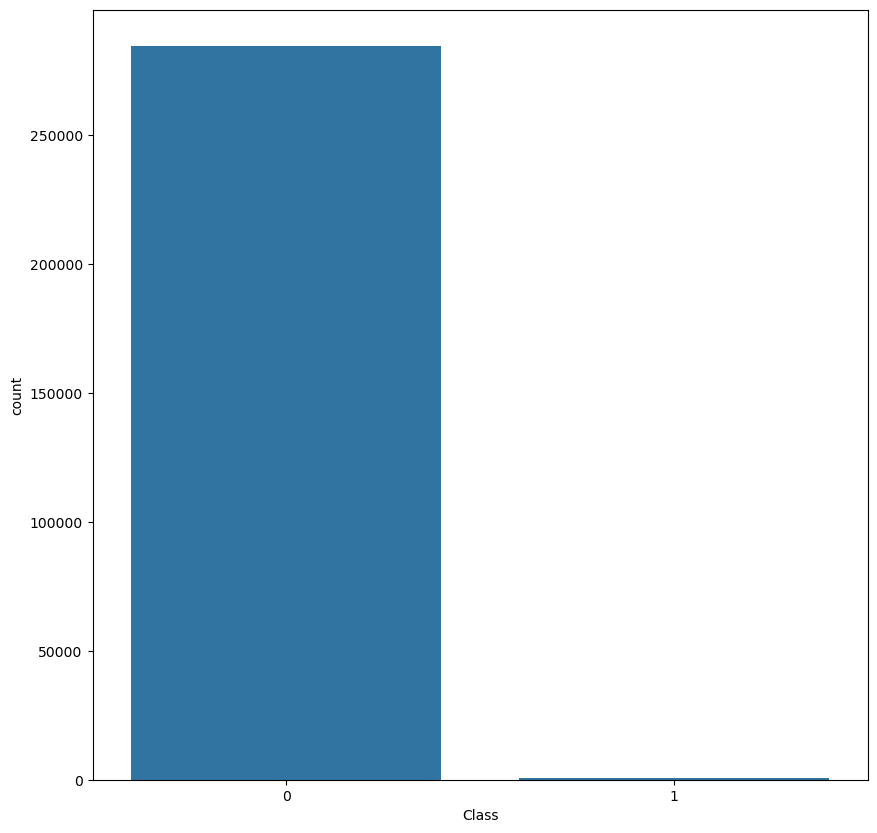

In [11]:
countplot_data(df, "Class")


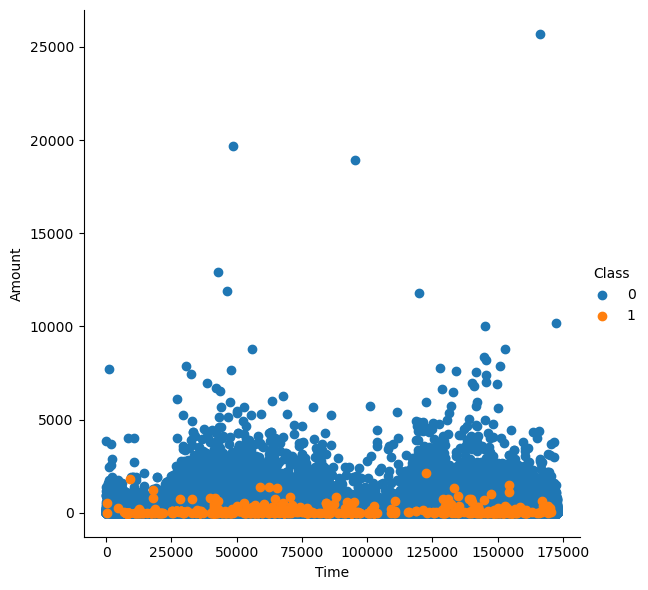

In [12]:
pairplot_data_grid(df, "Time", "Amount", "Class")

In [15]:
amount_more = 0
amount_less = 0
for i in range(df.shape[0]):
    if(df.iloc[i]["Amount"] < 2500):
        amount_less += 1
    else:
        amount_more += 1
print(amount_more)
print(amount_less)

449
284358


In [16]:
percentage_less = (amount_less/df.shape[0])*100
percentage_less

99.84234938045763

In [18]:
fraud = 0
legitimate = 1
for i in range(df.shape[0]):
    if(df.iloc[i]["Amount"]<2500):
        if(df.iloc[i]["Class"] == 0):
            legitimate += 1
        else:
            fraud+=1
print(fraud)
print(legitimate)

492
283867


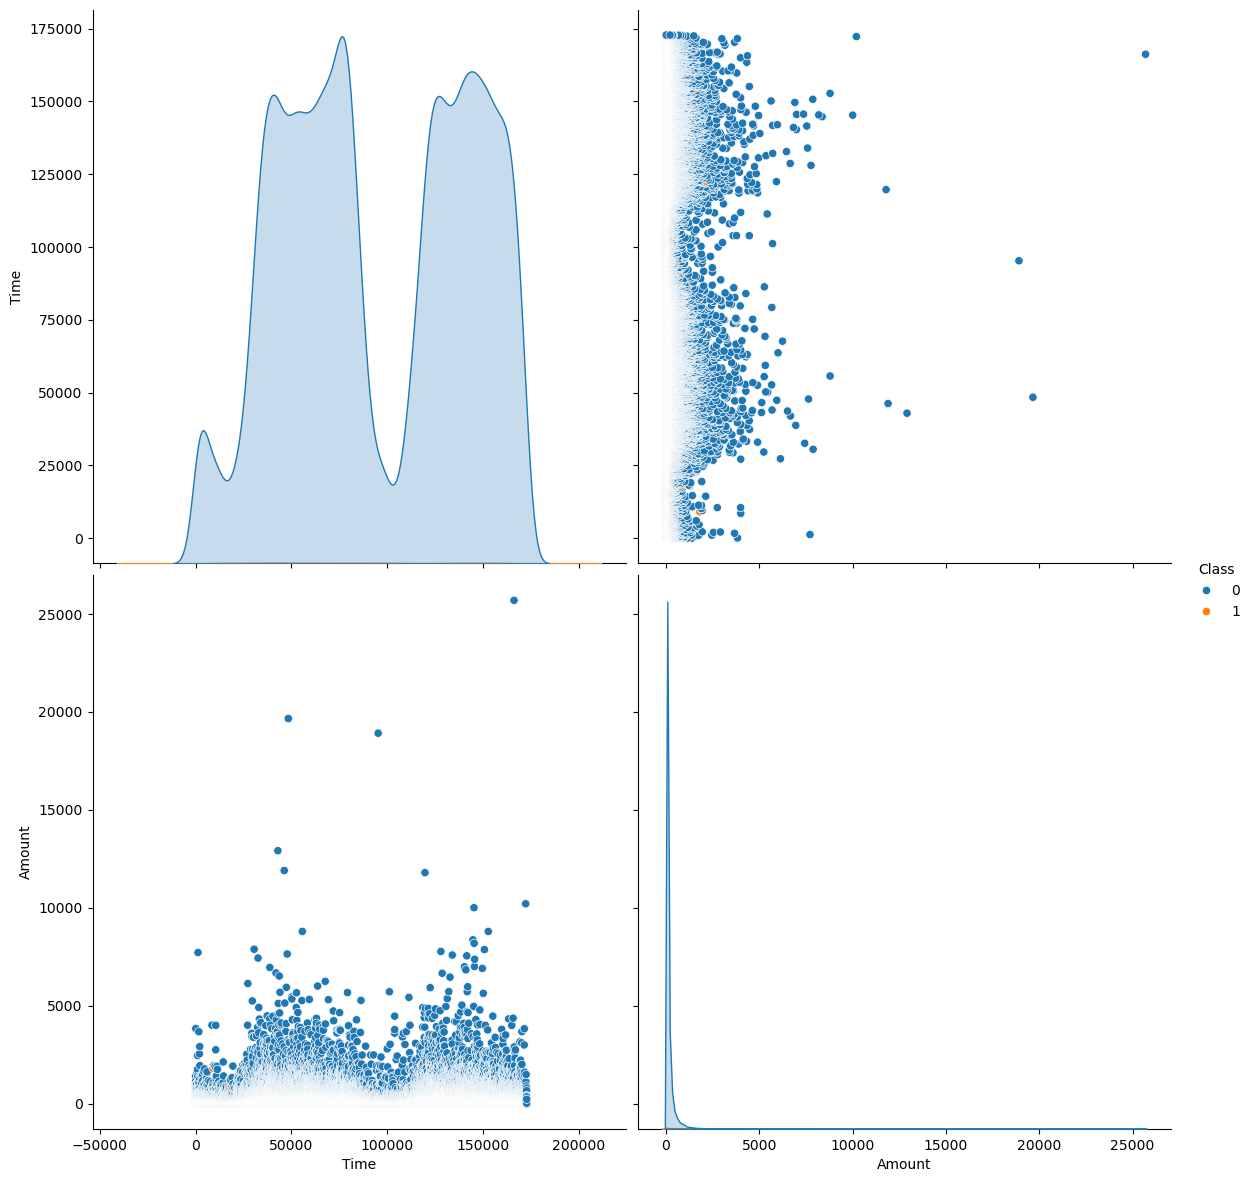

In [20]:
df_refine = df[["Time", "Amount", "Class"]]
sns.pairplot(df_refine, hue="Class", height=6)
plt.show()

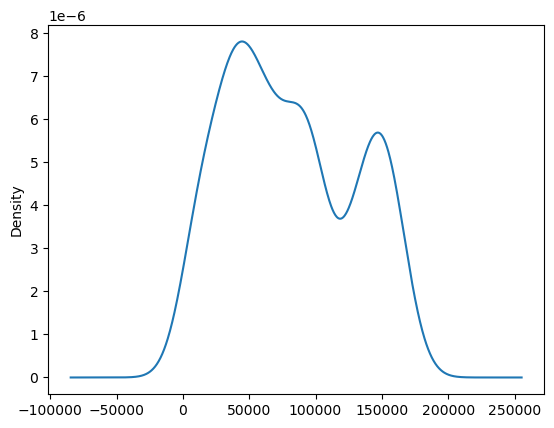

In [21]:
df[df["Class"] == 1]["Time"].plot(kind="kde")
plt.show() 

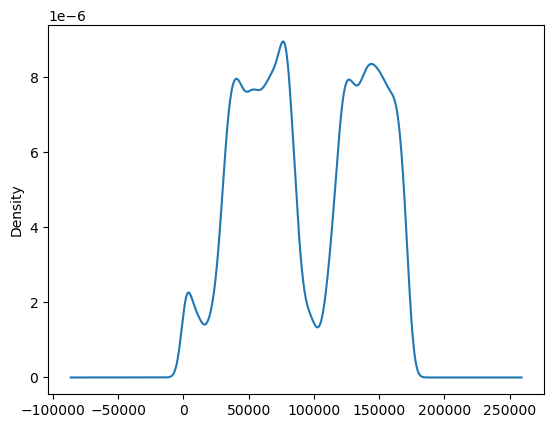

In [22]:
df[df["Class"] == 0]["Time"].plot(kind="kde")
plt.show()

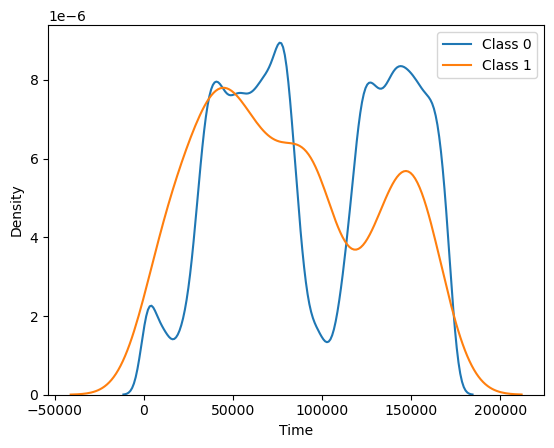

In [23]:
sns.kdeplot(
    data=df[df["Class"] == 0],
    x="Time",
    label="Class 0"
)

sns.kdeplot(
    data=df[df["Class"] == 1],
    x="Time",
    label="Class 1"
)

plt.legend()
plt.show()

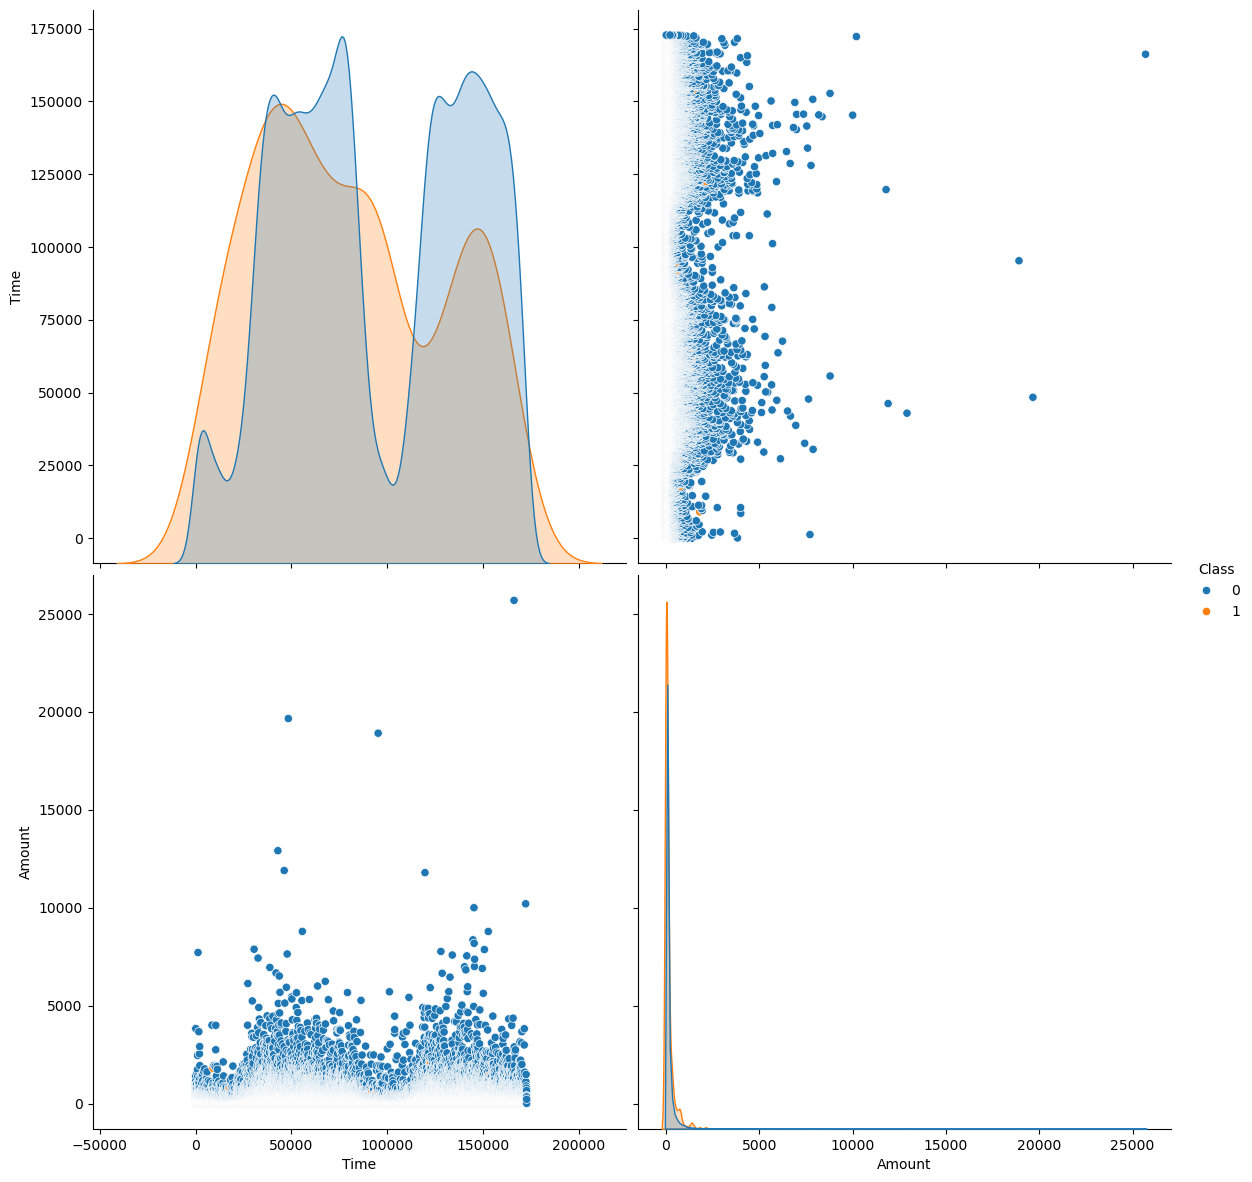

In [24]:
df_refine = df[["Time", "Amount", "Class"]]

sns.pairplot(
    df_refine,
    hue="Class",
    height=6,
    diag_kws={"common_norm": False}
)

plt.show()

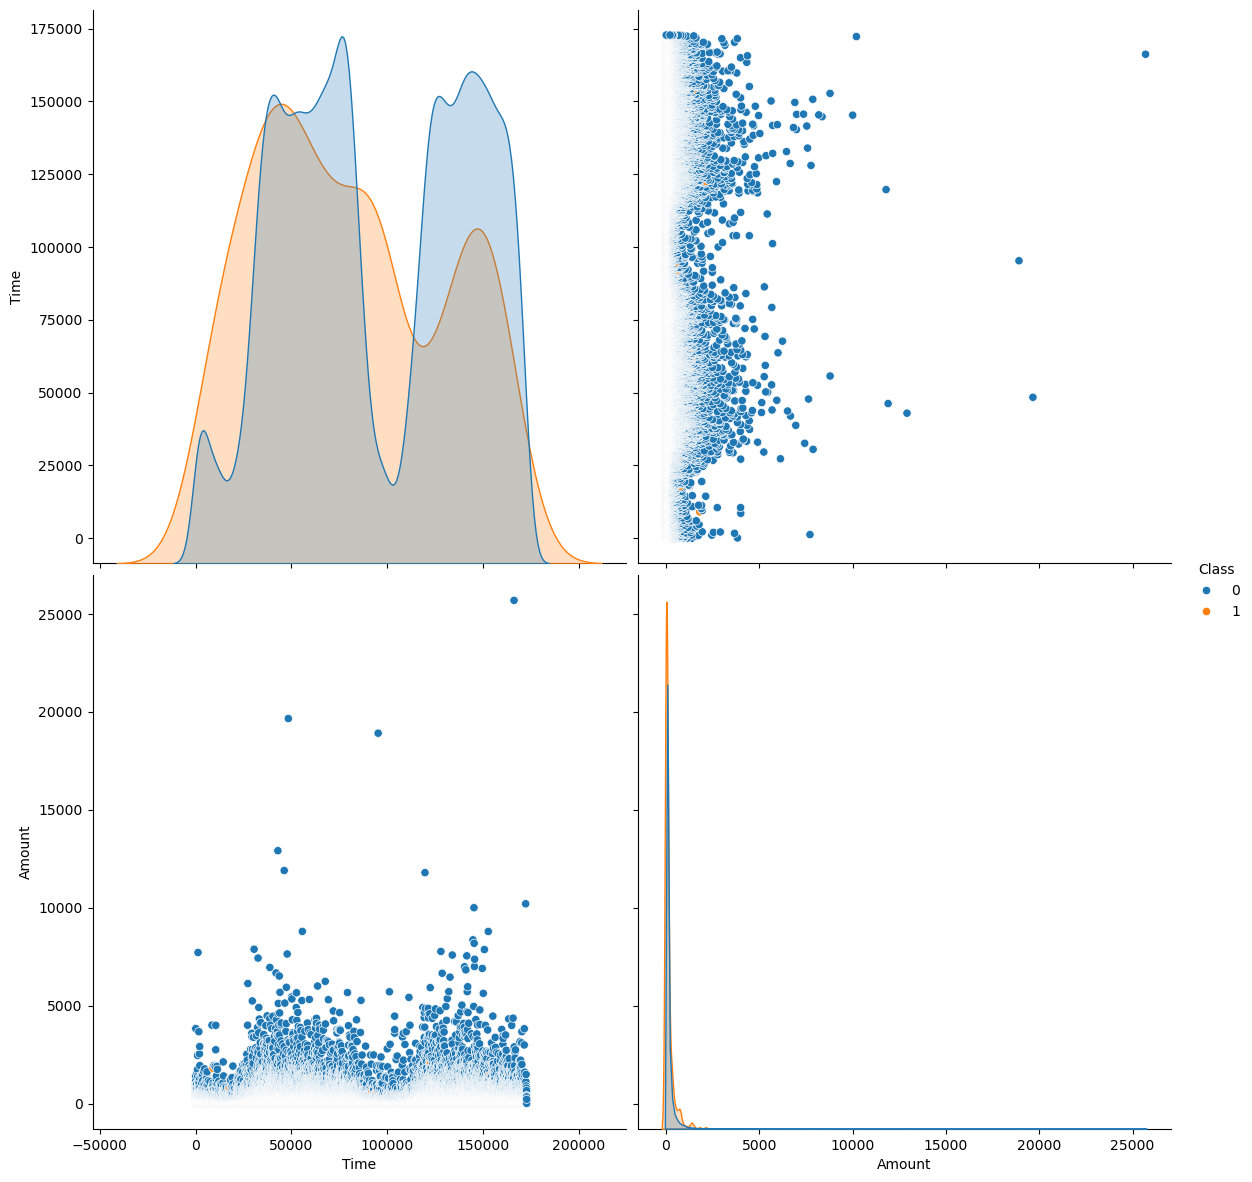

In [25]:
df_refine = df[["Time", "Amount", "Class"]]

sns.pairplot(
    df_refine,
    hue="Class",
    height=6,
    diag_kws={"common_norm": False}
)

plt.show()

In [26]:
df.Class.value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

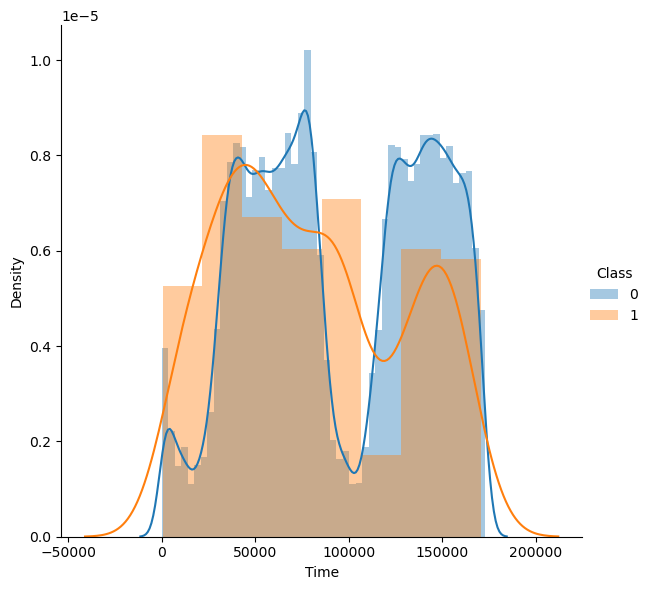

In [28]:
sns.FacetGrid(df_refine, hue="Class", height=6).map(sns.distplot,"Time").add_legend()
plt.show()

<Axes: >

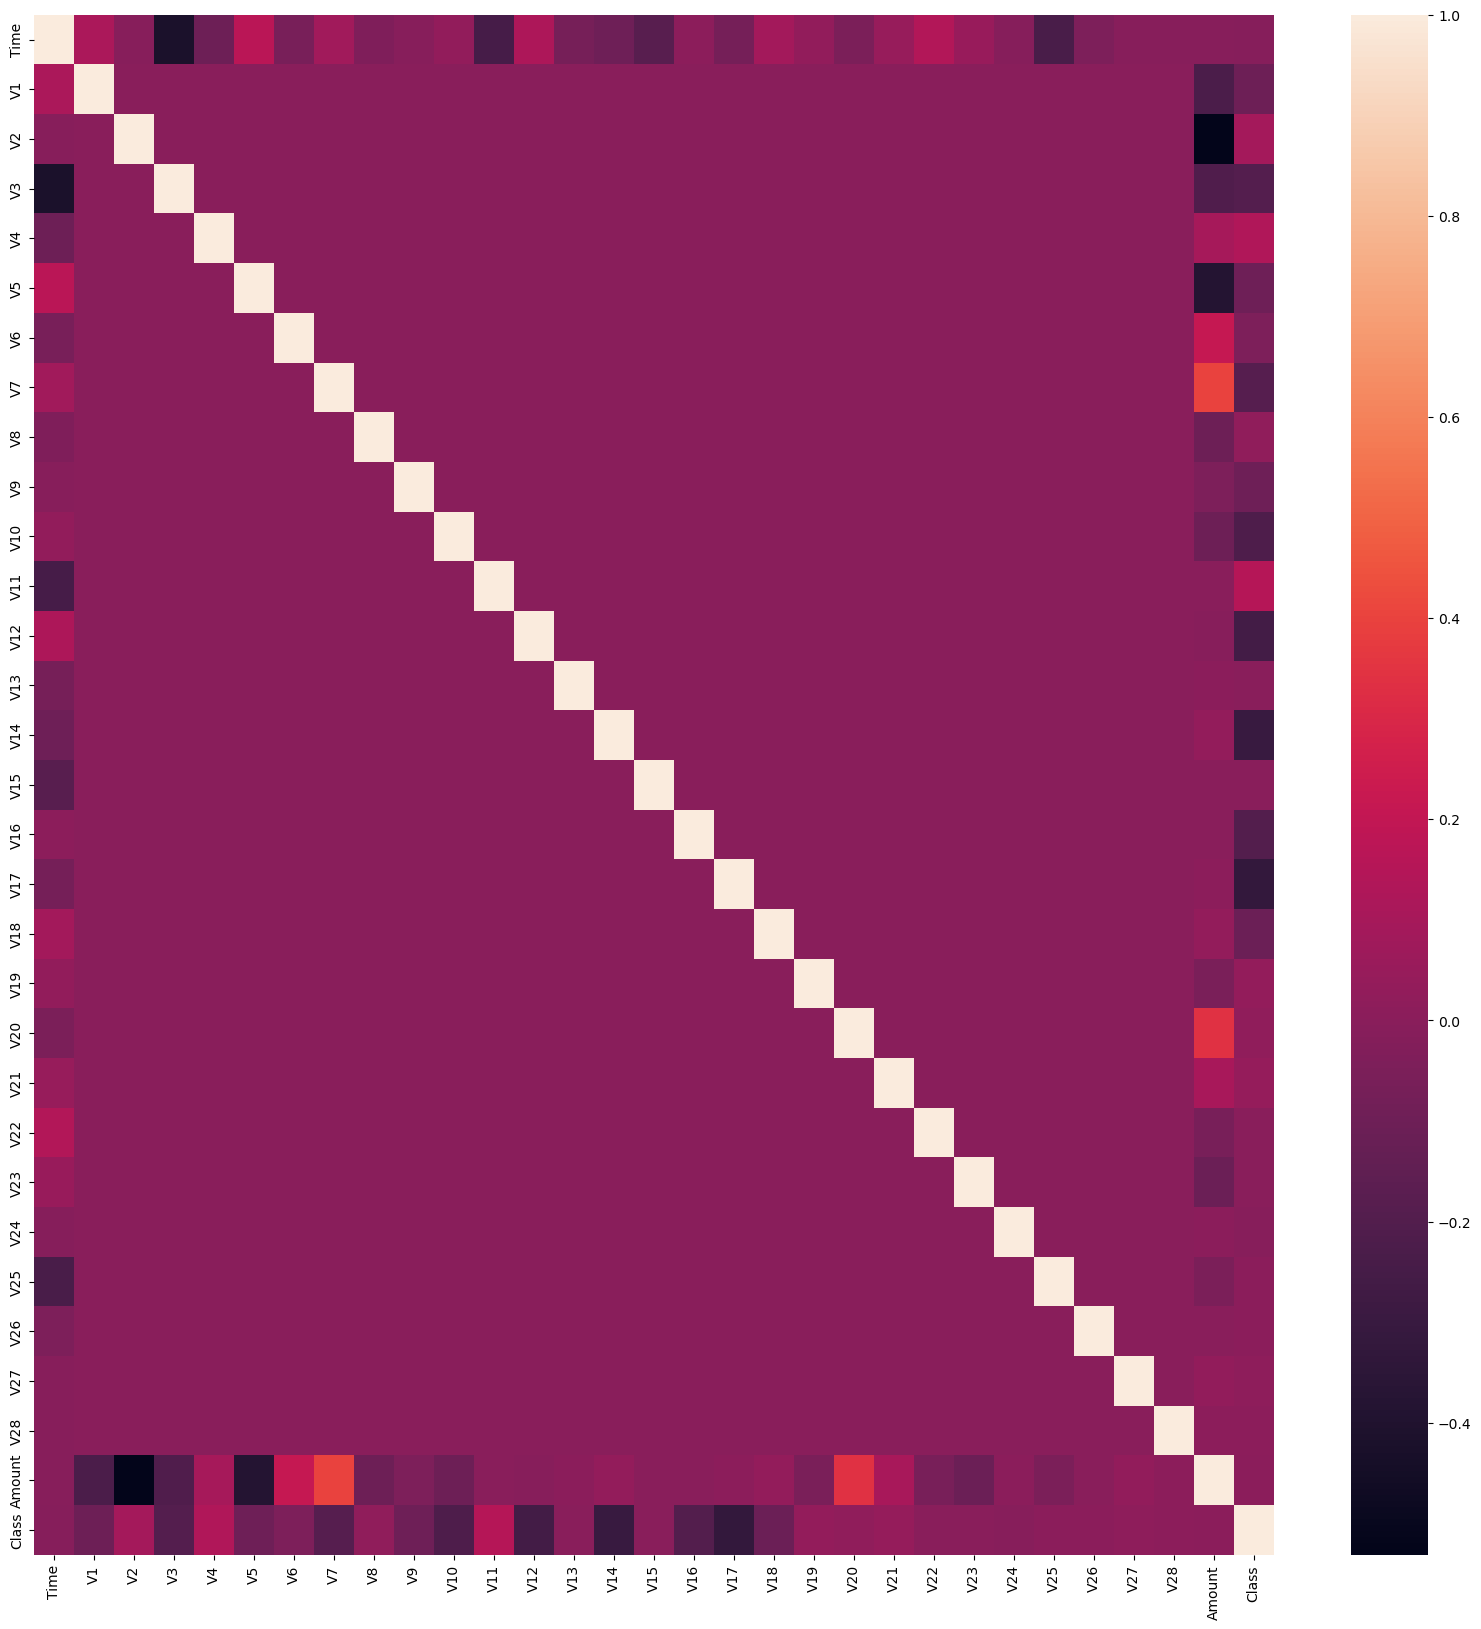

In [29]:
plt.figure(figsize=(20,20))
df_corr = df.corr()
sns.heatmap(df_corr)

In [30]:
X = df.drop(labels='Class', axis=1) # Features
y = df.loc[:,'Class']               # Target Variable


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

In [31]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

In [32]:
from sklearn.feature_selection import mutual_info_classif
mutual_infos = pd.Series(data=mutual_info_classif(X_res, y_res, discrete_features=False, random_state=1), index=X_train.columns)

In [33]:
mutual_infos.sort_values(ascending=False)

V14       0.535044
V10       0.464775
V12       0.456052
V17       0.438193
V4        0.427427
V11       0.404040
Amount    0.392909
V3        0.387187
V16       0.335317
V7        0.304171
V2        0.291484
V9        0.256678
Time      0.247989
V21       0.235010
V27       0.229914
V1        0.220736
V18       0.198262
V8        0.174371
V6        0.171973
V28       0.170495
V5        0.157362
V20       0.107488
V19       0.099836
V23       0.067332
V24       0.063567
V26       0.046974
V25       0.031606
V22       0.031539
V13       0.024931
V15       0.022442
dtype: float64

In [35]:
sns.countplot(y_res)

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x0000013138310860> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x000001313C606E80> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [36]:
scaler = StandardScaler()

X_res_scaled = scaler.fit_transform(X_res)
X_test_scaled = scaler.transform(X_test)

In [37]:
lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr.fit(X_res_scaled, y_res)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [38]:
y_pred_lr = lr.predict(X_test_scaled)

y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

In [39]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [40]:
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

Precision: 0.14725274725274726
Recall: 0.9054054054054054
F1 Score: 0.2533081285444234
ROC-AUC: 0.9871883431587987


In [41]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     85295
           1       0.15      0.91      0.25       148

    accuracy                           0.99     85443
   macro avg       0.57      0.95      0.62     85443
weighted avg       1.00      0.99      0.99     85443



In [42]:
print(confusion_matrix(y_test, y_pred_lr))

[[84519   776]
 [   14   134]]


In [43]:
from xgboost import XGBClassifier

In [44]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_res, y_res)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [45]:
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

In [46]:
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

Precision: 0.8543046357615894
Recall: 0.8716216216216216
F1 Score: 0.862876254180602
ROC-AUC: 0.9866050733305555


In [47]:
print(confusion_matrix(y_test, y_pred_xgb))

[[85273    22]
 [   19   129]]


In [48]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:
    y_pred_threshold = (y_prob_xgb >= threshold).astype(int)
    
    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)
    
    print(
        f"Threshold: {threshold} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.3 | Precision: 0.802 | Recall: 0.878 | F1: 0.839
Threshold: 0.4 | Precision: 0.832 | Recall: 0.872 | F1: 0.851
Threshold: 0.5 | Precision: 0.854 | Recall: 0.872 | F1: 0.863
Threshold: 0.6 | Precision: 0.864 | Recall: 0.858 | F1: 0.861
Threshold: 0.7 | Precision: 0.876 | Recall: 0.858 | F1: 0.867


In [49]:
for threshold in [0.3, 0.5, 0.7]:
    y_pred_threshold = (y_prob_xgb >= threshold).astype(int)
    
    print(f"\nThreshold: {threshold}")
    print(confusion_matrix(y_test, y_pred_threshold))


Threshold: 0.3
[[85263    32]
 [   18   130]]

Threshold: 0.5
[[85273    22]
 [   19   129]]

Threshold: 0.7
[[85277    18]
 [   21   127]]


In [50]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost"],
    "Precision": [precision_score(y_test, y_pred_lr),
                   precision_score(y_test, y_pred_xgb)],
    "Recall": [recall_score(y_test, y_pred_lr),
               recall_score(y_test, y_pred_xgb)],
    "F1 Score": [f1_score(y_test, y_pred_lr),
                 f1_score(y_test, y_pred_xgb)],
    "ROC-AUC": [roc_auc_score(y_test, y_prob_lr),
                roc_auc_score(y_test, y_prob_xgb)]
})

results

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.147253,0.905405,0.253308,0.987188
1,XGBoost,0.854305,0.871622,0.862876,0.986605
